Import package

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

Load Data

In [14]:
df = pd.read_csv('Traffic_Collision_Data.csv', low_memory=False)
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (621677, 18)

Columns:
['DR Number', 'Date Reported', 'Date Occurred', 'Time Occurred', 'Area ID', 'Area Name', 'Reporting District', 'Crime Code', 'Crime Code Description', 'MO Codes', 'Victim Age', 'Victim Sex', 'Victim Descent', 'Premise Code', 'Premise Description', 'Address', 'Cross Street', 'Location']


,DR Number,Date Reported,Date Occurred,Time Occurred,Area ID,Area Name,Reporting District,Crime Code,Crime Code Description,MO Codes,Victim Age,Victim Sex,Victim Descent,Premise Code,Premise Description,Address,Cross Street,Location
0,212013850,09/03/2021,09/02/2021,2335,20,Olympic,2021,997,TRAFFIC COLLISION,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,101.0,STREET,WILTON PL,6TH ST,"(34.063, -118.3141)"
1,221417787,10/17/2022,10/17/2022,1620,14,Pacific,1406,997,TRAFFIC COLLISION,4027 3011 3028 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)"
2,221418141,10/26/2022,10/26/2022,1135,14,Pacific,1434,997,TRAFFIC COLLISION,4027 3011 3025 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)"
3,222017859,12/01/2022,12/01/2022,230,20,Olympic,2044,997,TRAFFIC COLLISION,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,101.0,STREET,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)"
4,190319651,08/24/2019,08/24/2019,450,3,Southwest,356,997,TRAFFIC COLLISION,3036 3004 3026 3101 4003,22.0,M,H,101.0,STREET,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)"


In [15]:
# Keep only columns needed
cols_to_keep = [
    'DR Number',
    'Date Occurred',
    'Time Occurred',
    'Area ID',
    'Area Name',
    'MO Codes',
    'Victim Age',
    'Victim Sex',
    'Victim Descent',
    'Location'
]

df = df[cols_to_keep]
print(df.shape)
print(df.isnull().sum())

(621677, 10)
DR Number             0
Date Occurred         0
Time Occurred         0
Area ID               0
Area Name             0
MO Codes          87324
Victim Age        88194
Victim Sex        10697
Victim Descent    11648
Location              0
dtype: int64


In [16]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

DR Number           int64
Date Occurred      object
Time Occurred       int64
Area ID             int64
Area Name          object
MO Codes           object
Victim Age        float64
Victim Sex         object
Victim Descent     object
Location           object
dtype: object

Missing values:
DR Number             0
Date Occurred         0
Time Occurred         0
Area ID               0
Area Name             0
MO Codes          87324
Victim Age        88194
Victim Sex        10697
Victim Descent    11648
Location              0
dtype: int64


Combine date + time into a single datetime column

In [17]:
df['Time Occurred'] = df['Time Occurred'].astype(str).str.zfill(4) 
df['datetime'] = pd.to_datetime(
    df['Date Occurred'] + ' ' + df['Time Occurred'],
    format='%m/%d/%Y %H%M',
    errors='coerce'
)

print(f"Datetime nulls after parsing: {df['datetime'].isnull().sum()}")

Datetime nulls after parsing: 0


Extract Lat/Lon from Location

In [18]:
# Location column is in format "(lat, lon)"
df['Location'] = df['Location'].str.strip()
df['Latitude'] = df['Location'].str.extract(r'\(([^,]+),').astype(float)
df['Longitude'] = df['Location'].str.extract(r',\s*([^)]+)\)').astype(float)

print(f"Null Latitude: {df['Latitude'].isnull().sum()}")
print(f"Null Longitude: {df['Longitude'].isnull().sum()}")
print(f"Zero coordinates: {((df['Latitude'] == 0) | (df['Longitude'] == 0)).sum()}")

Null Latitude: 0
Null Longitude: 0
Zero coordinates: 965


Clean & Filter

In [19]:
df_clean = df.copy()

# 1. Drop rows where MO Codes is null (target variable)
df_clean = df_clean[df_clean['MO Codes'].notnull()]

# 2. Drop rows where Victim Age is null
df_clean = df_clean[df_clean['Victim Age'].notnull()]

# 3. Drop rows where Victim Sex is null
df_clean = df_clean[df_clean['Victim Sex'].notnull()]

# 4. Drop rows where Victim Sex is null
df_clean = df_clean[df_clean['Victim Descent'].notnull()]

# 5. Drop invalid/zero coordinates
df_clean = df_clean[
    (df_clean['Latitude'] != 0) &
    (df_clean['Longitude'] != 0)
]

# 6. Filter to LA bounding box
df_clean = df_clean[
    (df_clean['Latitude'].between(33.7, 34.35)) &
    (df_clean['Longitude'].between(-118.7, -118.15))
]

# 7. Drop duplicates
df_clean = df_clean.drop_duplicates(subset='DR Number')

print(f"Original rows : {len(df)}")
print(f"Cleaned rows  : {len(df_clean)}")
print(f"Rows dropped  : {len(df) - len(df_clean)}")

Original rows : 621677
Cleaned rows  : 452646
Rows dropped  : 169031


In [20]:
df_clean

,DR Number,Date Occurred,Time Occurred,Area ID,Area Name,MO Codes,Victim Age,Victim Sex,Victim Descent,Location,datetime,Latitude,Longitude
0,212013850,09/02/2021,2335,20,Olympic,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,"(34.063, -118.3141)",2021-09-02 23:35:00,34.0630,-118.3141
3,222017859,12/01/2022,0230,20,Olympic,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,"(34.0545, -118.3009)",2022-12-01 02:30:00,34.0545,-118.3009
4,190319651,08/24/2019,0450,3,Southwest,3036 3004 3026 3101 4003,22.0,M,H,"(34.0255, -118.3002)",2019-08-24 04:50:00,34.0255,-118.3002
5,190319680,08/30/2019,2320,3,Southwest,3037 3006 3028 3030 3039 3101 4003,30.0,F,H,"(34.0256, -118.3089)",2019-08-30 23:20:00,34.0256,-118.3089
7,190127578,11/20/2019,0350,1,Central,0605 3101 3401 3701 3011 3034,21.0,M,H,"(34.0492, -118.2391)",2019-11-20 03:50:00,34.0492,-118.2391
...,...,...,...,...,...,...,...,...,...,...,...,...,...
621671,251004180,02/22/2025,1750,10,West Valley,3009 3024 4010 3033 3035 3037 3101,25.0,M,O,"(34.1688, -118.5356)",2025-02-22 17:50:00,34.1688,-118.5356
621673,251504225,03/06/2025,0810,15,N Hollywood,3004 3026 3033 3034 3036,25.0,F,W,"(34.1722, -118.3703)",2025-03-06 08:10:00,34.1722,-118.3703
621674,251604130,02/24/2025,0910,16,Foothill,3012 3036 3103 3002 3028 4026,35.0,M,W,"(34.2602, -118.3395)",2025-02-24 09:10:00,34.2602,-118.3395
621675,251604153,03/07/2025,1510,16,Foothill,3008 3026 4026 3033 3034 3037 3602,64.0,M,H,"(34.2752, -118.4133)",2025-03-07 15:10:00,34.2752,-118.4133


In [21]:
print("\nMissing values:")
print(df_clean.isnull().sum())


Missing values:
DR Number         0
Date Occurred     0
Time Occurred     0
Area ID           0
Area Name         0
MO Codes          0
Victim Age        0
Victim Sex        0
Victim Descent    0
Location          0
datetime          0
Latitude          0
Longitude         0
dtype: int64


Save Cleaned Data

In [22]:
df_clean.to_csv('collisions_clean.csv', index=False)
print("Saved collisions_clean.csv")

Saved collisions_clean.csv


# EDA — Traffic Collision Data (Los Angeles)
**Input:** `collisions_clean.csv` (Phase 1 output, 452,646 rows)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
%matplotlib inline

df = pd.read_csv('collisions_clean.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
print(f"Shape: {df.shape}")
print(df.columns.tolist())

Shape: (452646, 13)
['DR Number', 'Date Occurred', 'Time Occurred', 'Area ID', 'Area Name', 'MO Codes', 'Victim Age', 'Victim Sex', 'Victim Descent', 'Location', 'datetime', 'Latitude', 'Longitude']


## 1. Feature Engineering

In [24]:
# Temporal features
df['Hour']      = df['datetime'].dt.hour
df['DayOfWeek'] = df['datetime'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5,6]).astype(int)
df['Year']      = df['datetime'].dt.year
df['Month']     = df['datetime'].dt.month

def assign_time_period(h):
    if h < 6:   return 'Late Night'
    elif h < 10: return 'AM Peak'
    elif h < 16: return 'Midday'
    elif h < 20: return 'PM Peak'
    else:        return 'Evening'
df['TimePeriod'] = df['Hour'].apply(assign_time_period)

# Demographic features
age_bins   = [0,17,25,35,50,65,99]
age_labels = ['<18','18-25','26-35','36-50','51-65','65+']
df['AgeGroup'] = pd.cut(df['Victim Age'], bins=age_bins, labels=age_labels)
df['Sex'] = df['Victim Sex'].map({'M':'Male','F':'Female'}).fillna('Unknown')

descent_map = {
    'H':'Hispanic','W':'White','B':'Black','A':'Asian',
    'O':'Other','X':'Unknown','K':'Korean','F':'Filipino',
    'C':'Chinese','J':'Japanese','V':'Vietnamese'
}
df['Descent'] = df['Victim Descent'].map(descent_map).fillna('Other')

print("Features added.")

Features added.


## 2. Severity Label (Target Variable)

In [25]:
SEV_PRIORITY = ['3027','3024','3025','3026','3028']
SEV_LABEL = {'3027':'Fatal','3024':'Severe Injury',
             '3025':'Visible Injury','3026':'Complaint of Pain','3028':'Non-Injury'}
SEV_NUM   = {'3027':4,'3024':3,'3025':2,'3026':1,'3028':0}
SEV_ORDER = ['Fatal','Severe Injury','Visible Injury','Complaint of Pain','Non-Injury']
SEV_COLORS= ['#d62728','#ff7f0e','#ffbb78','#aec7e8','#1f77b4']

def extract_severity(mo):
    if pd.isna(mo): return None, None
    codes = set(mo.split())
    for c in SEV_PRIORITY:
        if c in codes: return SEV_LABEL[c], SEV_NUM[c]
    return None, None

df[['Severity','Severity_Num']] = df['MO Codes'].apply(
    lambda x: pd.Series(extract_severity(x)))

df_sev = df[df['Severity'].notna()].copy()
print(f"Records with severity label: {len(df_sev):,}")
print()
for s in SEV_ORDER: 
    n = (df_sev['Severity']==s).sum() 
    print(f"  {s:<22}: {n:>6,}  ({n/len(df_sev)*100:.1f}%)")

Records with severity label: 360,687

  Fatal                 :  3,059  (0.8%)
  Severe Injury         : 14,797  (4.1%)
  Visible Injury        : 58,646  (16.3%)
  Complaint of Pain     : 135,877  (37.7%)
  Non-Injury            : 148,308  (41.1%)


In [26]:
# Collision type flags
def has_code(mo, code):
    if pd.isna(mo): return 0
    return 1 if code in mo.split() else 0

FLAG_MAP = {
    'TC_VehVsPed':  '3003', 'TC_VehVsBike': '3008',
    'TC_VehVsVeh':  '3004', 'TC_VehVsMC':   '3009',
    'TC_HitRun':    '3029', 'TC_AtIntersect':'3036',
}
for col, code_val in FLAG_MAP.items():
    df_sev[col] = df_sev['MO Codes'].apply(lambda x: has_code(x, code_val))

print("Collision type flags added.")

Collision type flags added.


## 3. Severity Distribution

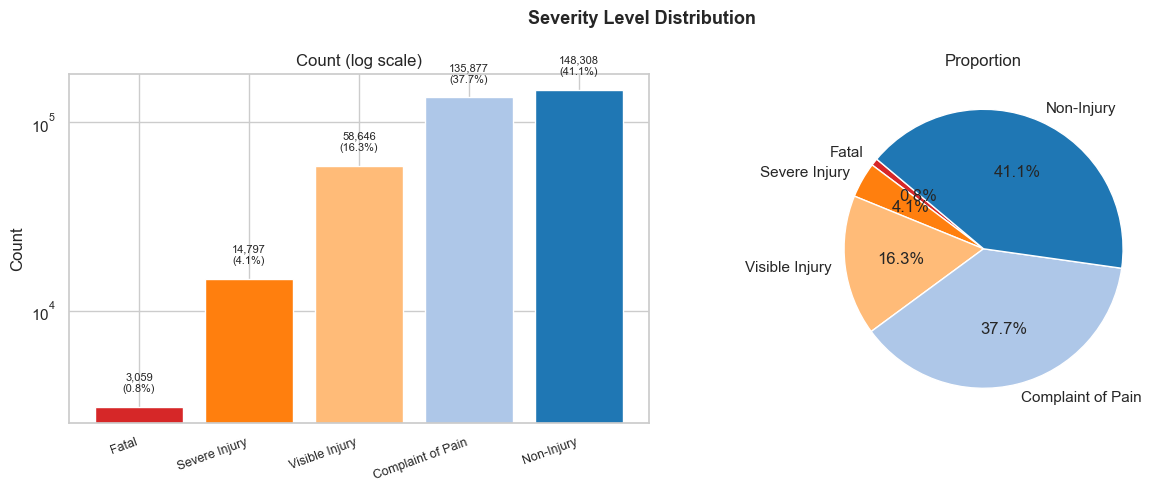

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Severity Level Distribution', fontsize=13, fontweight='bold')

counts = df_sev['Severity'].value_counts().reindex(SEV_ORDER)
axes[0].bar(range(len(SEV_ORDER)), counts.values, color=SEV_COLORS, edgecolor='white')
axes[0].set_xticks(range(len(SEV_ORDER)))
axes[0].set_xticklabels(SEV_ORDER, rotation=20, ha='right', fontsize=9)
axes[0].set_yscale('log')
axes[0].set_title('Count (log scale)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v*1.2, f'{v:,}\n({v/len(df_sev)*100:.1f}%)', ha='center', fontsize=8)

axes[1].pie(counts.values, labels=SEV_ORDER, colors=SEV_COLORS,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('fig_severity_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Temporal Analysis

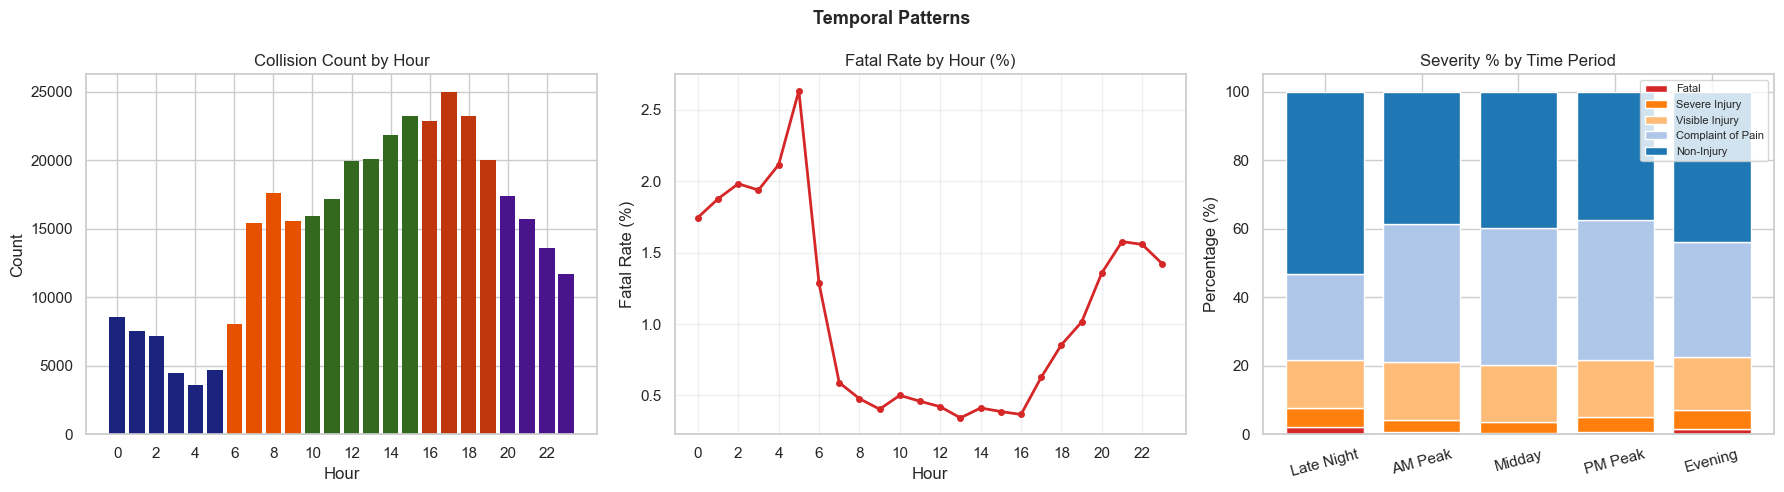

In [28]:
TP_ORDER = ['Late Night','AM Peak','Midday','PM Peak','Evening']
hourly_total = df_sev.groupby('Hour').size()
hourly_fatal = df_sev[df_sev['Severity']=='Fatal'].groupby('Hour').size()
fatal_rate   = (hourly_fatal/hourly_total*100).reindex(range(24), fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Temporal Patterns', fontsize=13, fontweight='bold')

# Hourly count
hour_colors = ['#1a237e' if h<6 else '#e65100' if h<10
               else '#33691e' if h<16 else '#bf360c' if h<20
               else '#4a148c' for h in range(24)]
axes[0].bar(range(24), hourly_total.values, color=hour_colors, edgecolor='none')
axes[0].set_title('Collision Count by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0,24,2))

# Fatal rate by hour
axes[1].plot(range(24), fatal_rate.values, marker='o', color='#d62728', linewidth=2, markersize=4)
axes[1].set_title('Fatal Rate by Hour (%)')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fatal Rate (%)')
axes[1].set_xticks(range(0,24,2))
axes[1].grid(True, alpha=0.3)

# Time period × severity stacked
tp_sev = df_sev.groupby(['TimePeriod','Severity']).size().unstack(fill_value=0).reindex(TP_ORDER)
tp_pct = tp_sev.div(tp_sev.sum(axis=1), axis=0)*100
bottom = np.zeros(len(TP_ORDER))
for sev, color in zip(SEV_ORDER, SEV_COLORS):
    if sev in tp_pct.columns:
        vals = tp_pct[sev].values
        axes[2].bar(TP_ORDER, vals, bottom=bottom, color=color, label=sev, edgecolor='white')
        bottom += vals
axes[2].set_title('Severity % by Time Period')
axes[2].set_ylabel('Percentage (%)')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

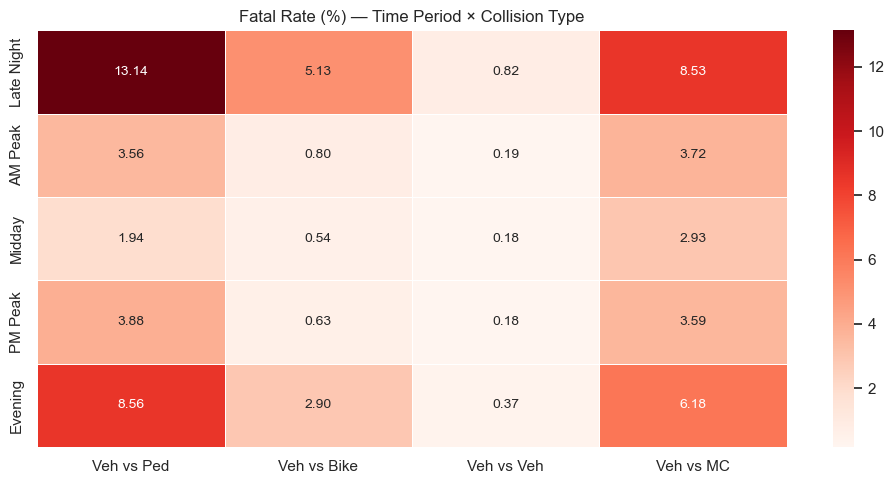

In [29]:
type_flags = ['TC_VehVsPed','TC_VehVsBike','TC_VehVsVeh','TC_VehVsMC']
type_labels = ['Veh vs Ped','Veh vs Bike','Veh vs Veh','Veh vs MC']

grid = pd.DataFrame(index=TP_ORDER, columns=type_labels, dtype=float)
for tp in TP_ORDER:
    sub_tp = df_sev[df_sev['TimePeriod']==tp]
    for col, label in zip(type_flags, type_labels):
        sub = sub_tp[sub_tp[col]==1]
        grid.loc[tp, label] = (sub['Severity']=='Fatal').mean()*100 if len(sub)>0 else np.nan

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(grid.astype(float), ax=ax, cmap='Reds',
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size':10})
ax.set_title('Fatal Rate (%) — Time Period × Collision Type', fontsize=12)
plt.tight_layout()
plt.savefig('fig_timeperiod_type.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Demographic Analysis

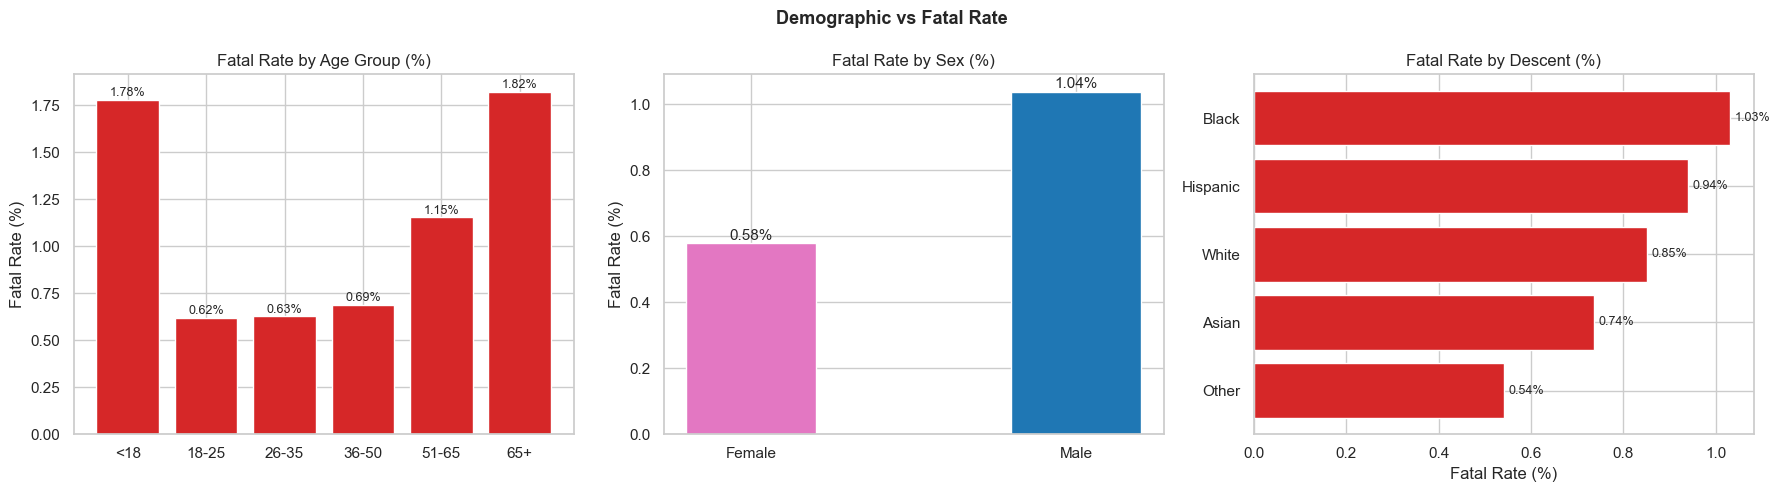

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Demographic vs Fatal Rate', fontsize=13, fontweight='bold')

# Age
AGE_ORDER = ['<18','18-25','26-35','36-50','51-65','65+']
age_sev = (df_sev.groupby(['AgeGroup','Severity']).size()
           .unstack(fill_value=0).reindex(index=AGE_ORDER, columns=SEV_ORDER, fill_value=0))
fatal_by_age = (age_sev['Fatal']/age_sev.sum(axis=1)*100)
axes[0].bar(AGE_ORDER, fatal_by_age.values, color='#d62728', edgecolor='white')
axes[0].set_title('Fatal Rate by Age Group (%)')
axes[0].set_ylabel('Fatal Rate (%)')
for i, v in enumerate(fatal_by_age.values):
    axes[0].text(i, v+0.02, f'{v:.2f}%', ha='center', fontsize=9)

# Sex
df_sex = df_sev[df_sev['Sex'].isin(['Male','Female'])]
sex_sev = (df_sex.groupby(['Sex','Severity']).size()
           .unstack(fill_value=0).reindex(columns=SEV_ORDER, fill_value=0))
fatal_by_sex = (sex_sev['Fatal']/sex_sev.sum(axis=1)*100)
axes[1].bar(fatal_by_sex.index, fatal_by_sex.values,
            color=['#e377c2','#1f77b4'], edgecolor='white', width=0.4)
axes[1].set_title('Fatal Rate by Sex (%)')
axes[1].set_ylabel('Fatal Rate (%)')
for i, (idx, v) in enumerate(fatal_by_sex.items()):
    axes[1].text(i, v+0.01, f'{v:.2f}%', ha='center', fontsize=11)

# Descent
major = ['Hispanic','White','Black','Asian','Other']
df_desc = df_sev[df_sev['Descent'].isin(major)]
desc_sev = (df_desc.groupby(['Descent','Severity']).size()
            .unstack(fill_value=0).reindex(index=major, columns=SEV_ORDER, fill_value=0))
fatal_by_desc = (desc_sev['Fatal']/desc_sev.sum(axis=1)*100).sort_values()
axes[2].barh(fatal_by_desc.index, fatal_by_desc.values, color='#d62728', edgecolor='white')
axes[2].set_title('Fatal Rate by Descent (%)')
axes[2].set_xlabel('Fatal Rate (%)')
for i, v in enumerate(fatal_by_desc.values):
    axes[2].text(v+0.01, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_demographic.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Collision Type & Contributing Conditions

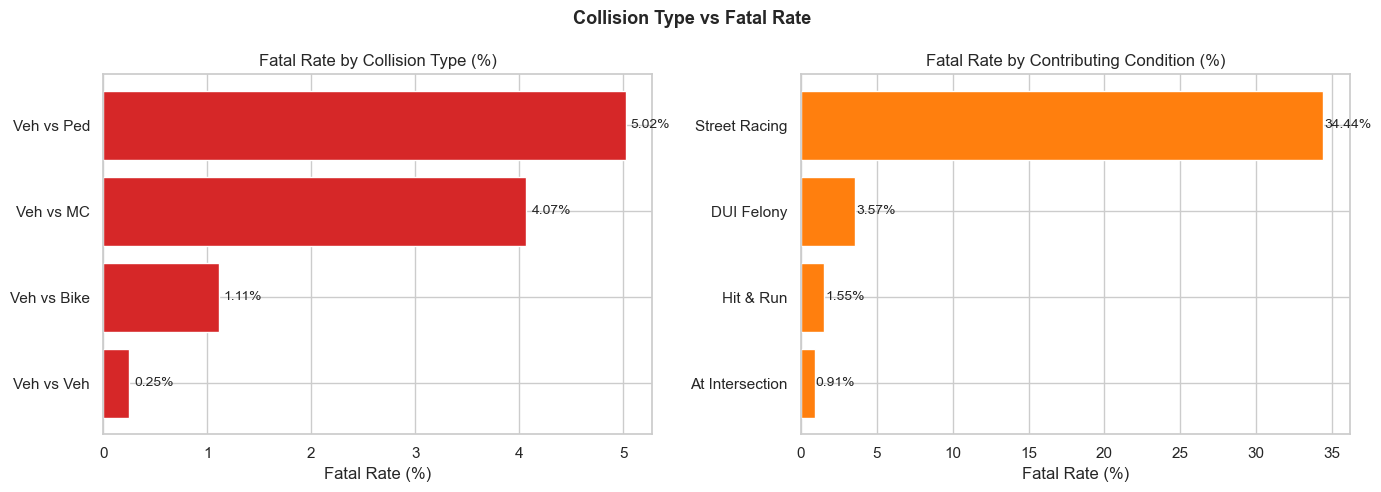

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Collision Type vs Fatal Rate', fontsize=13, fontweight='bold')

# Collision type fatal rate
type_res = {}
for col, label in zip(type_flags, type_labels):
    sub = df_sev[df_sev[col]==1]
    type_res[label] = (sub['Severity']=='Fatal').mean()*100

type_series = pd.Series(type_res).sort_values()
axes[0].barh(type_series.index, type_series.values, color='#d62728', edgecolor='white')
axes[0].set_title('Fatal Rate by Collision Type (%)')
axes[0].set_xlabel('Fatal Rate (%)')
for i, v in enumerate(type_series.values):
    axes[0].text(v+0.05, i, f'{v:.2f}%', va='center', fontsize=10)

# Contributing conditions
cond_flags  = ['TC_HitRun','TC_AtIntersect']
cond_labels = ['Hit & Run','At Intersection']
cond_res = {}
for col, label in zip(cond_flags, cond_labels):
    sub = df_sev[df_sev[col]==1]
    cond_res[label] = (sub['Severity']=='Fatal').mean()*100

# Also add DUI and Street Racing from MO Codes
for code_val, label in [('3038','DUI Felony'),('3040','Street Racing')]:
    df_sev[f'flag_{code_val}'] = df_sev['MO Codes'].apply(lambda x: has_code(x, code_val))
    sub = df_sev[df_sev[f'flag_{code_val}']==1]
    cond_res[label] = (sub['Severity']=='Fatal').mean()*100

cond_series = pd.Series(cond_res).sort_values()
axes[1].barh(cond_series.index, cond_series.values, color='#ff7f0e', edgecolor='white')
axes[1].set_title('Fatal Rate by Contributing Condition (%)')
axes[1].set_xlabel('Fatal Rate (%)')
for i, v in enumerate(cond_series.values):
    axes[1].text(v+0.05, i, f'{v:.2f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig_collision_type.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Class Imbalance Report

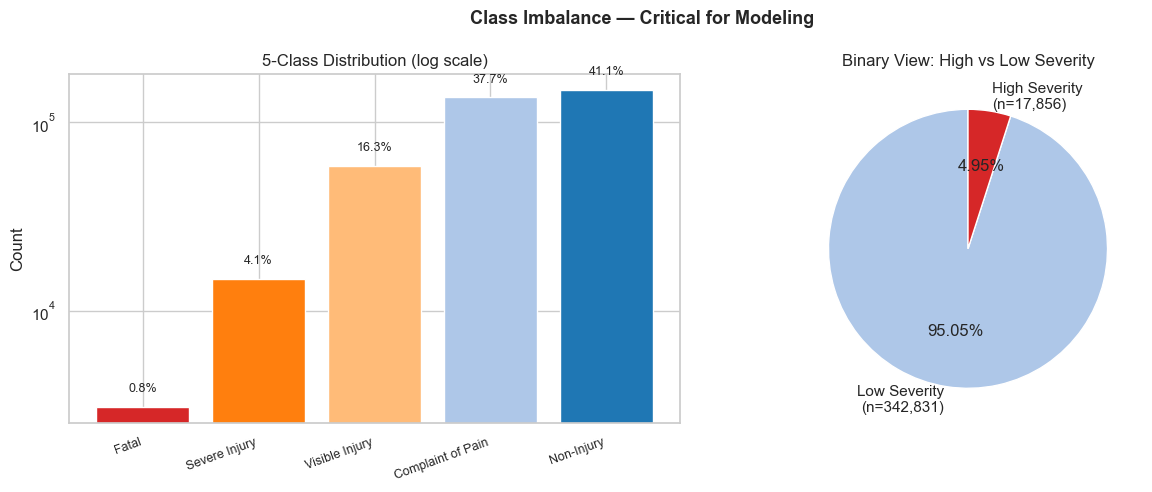

Fatal rate: 0.85%


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Class Imbalance — Critical for Modeling', fontsize=13, fontweight='bold')

counts = df_sev['Severity'].value_counts().reindex(SEV_ORDER)
axes[0].bar(range(len(SEV_ORDER)), counts.values, color=SEV_COLORS, edgecolor='white')
axes[0].set_xticks(range(len(SEV_ORDER)))
axes[0].set_xticklabels(SEV_ORDER, rotation=20, ha='right', fontsize=9)
axes[0].set_yscale('log')
axes[0].set_title('5-Class Distribution (log scale)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v * 1.2, f'{v/len(df_sev)*100:.1f}%', ha='center', fontsize=9)

high = df_sev['Severity'].isin(['Fatal', 'Severe Injury']).sum()
low  = len(df_sev) - high
axes[1].pie(
    [low, high],
    labels=[f'Low Severity\n(n={low:,})', f'High Severity\n(n={high:,})'],
    autopct='%1.2f%%',
    colors=['#aec7e8', '#d62728'],
    startangle=90
)
axes[1].set_title('Binary View: High vs Low Severity')

plt.tight_layout()
plt.savefig('fig_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Fatal rate: {(df_sev['Severity']=='Fatal').mean()*100:.2f}%")

## 8. Spatial EDA

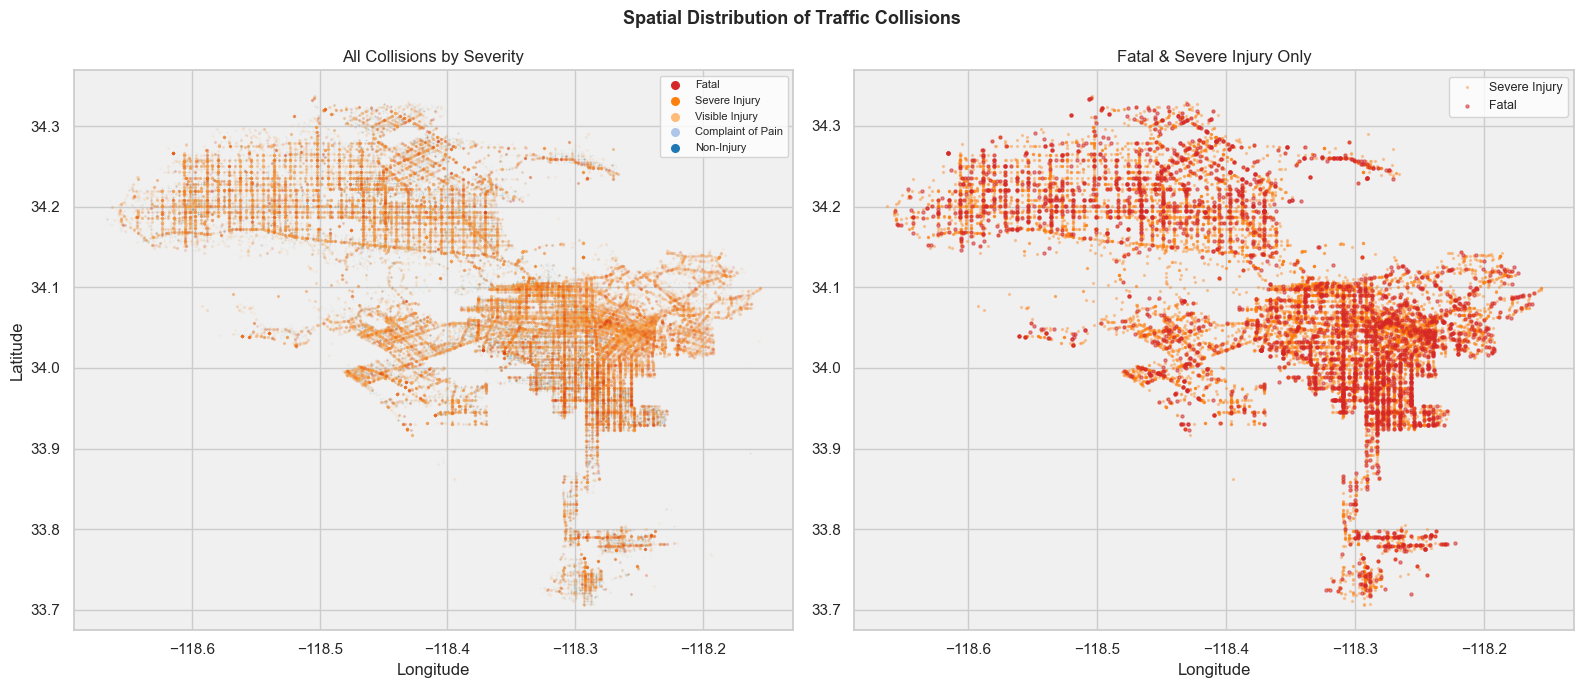

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Spatial Distribution of Traffic Collisions', fontsize=13, fontweight='bold')

# All collisions
for sev, color in reversed(list(zip(SEV_ORDER, SEV_COLORS))):
    sub = df_sev[df_sev['Severity']==sev]
    alpha = 0.02 if sev in ['Non-Injury','Complaint of Pain'] else 0.08
    size  = 0.2  if sev in ['Non-Injury','Complaint of Pain'] else 2
    axes[0].scatter(sub['Longitude'], sub['Latitude'],
                    c=color, s=size, alpha=alpha, rasterized=True)
for sev, color in zip(SEV_ORDER, SEV_COLORS):
    axes[0].scatter([], [], c=color, s=30, label=sev)
axes[0].set_title('All Collisions by Severity')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(fontsize=8)
axes[0].set_facecolor('#f0f0f0')

# Fatal only
df_fatal = df_sev[df_sev['Severity']=='Fatal']
df_severe = df_sev[df_sev['Severity']=='Severe Injury']
axes[1].scatter(df_severe['Longitude'], df_severe['Latitude'],
                c='#ff7f0e', s=2, alpha=0.3, label='Severe Injury', rasterized=True)
axes[1].scatter(df_fatal['Longitude'], df_fatal['Latitude'],
                c='#d62728', s=5, alpha=0.5, label='Fatal', rasterized=True)
axes[1].set_title('Fatal & Severe Injury Only')
axes[1].set_xlabel('Longitude')
axes[1].legend(fontsize=9)
axes[1].set_facecolor('#f0f0f0')

plt.tight_layout()
plt.savefig('fig_spatial_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

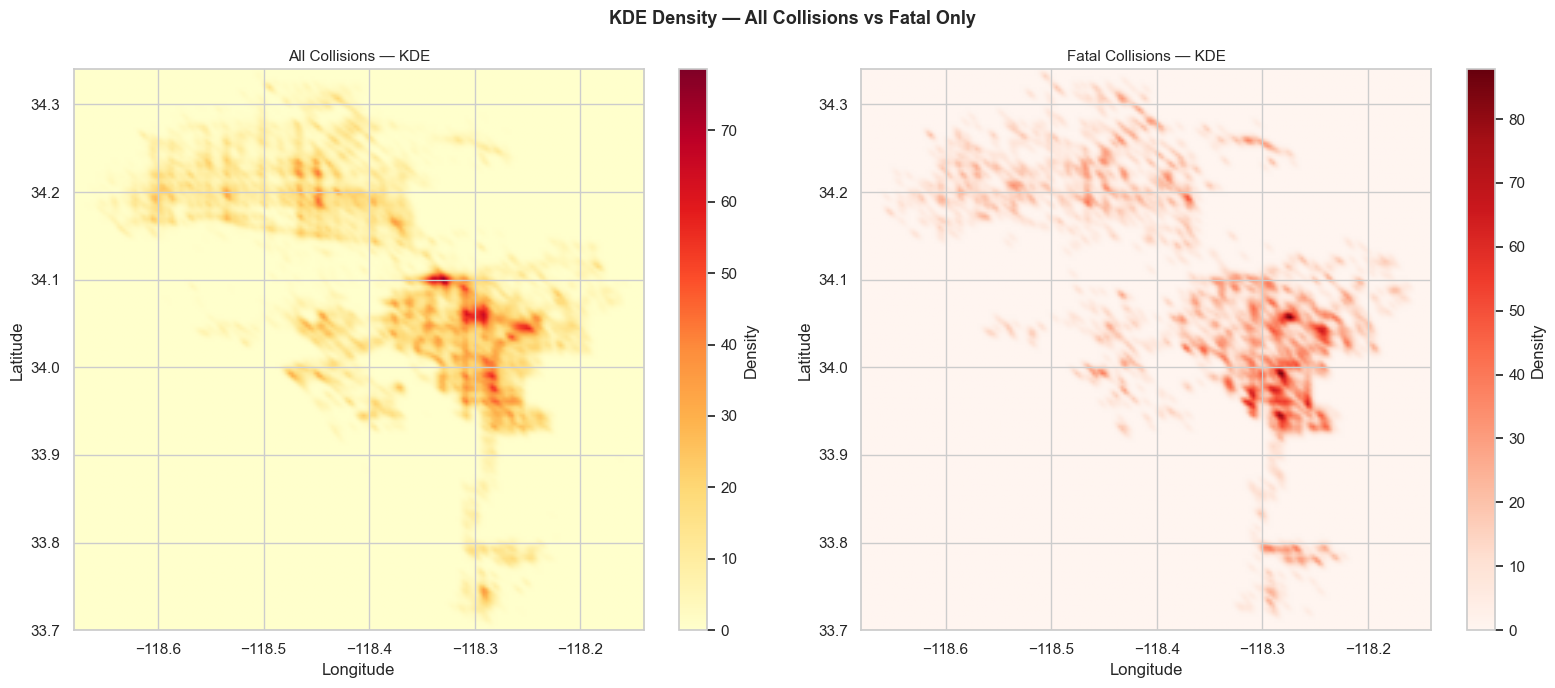

In [34]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('KDE Density — All Collisions vs Fatal Only', fontsize=13, fontweight='bold')

def plot_kde(ax, lons, lats, cmap, title, n_grid=200):
    lon_min, lon_max = -118.68, -118.14
    lat_min, lat_max =  33.70,   34.34
    lon_grid = np.linspace(lon_min, lon_max, n_grid)
    lat_grid = np.linspace(lat_min, lat_max, n_grid)
    LON, LAT = np.meshgrid(lon_grid, lat_grid)
    positions = np.vstack([LON.ravel(), LAT.ravel()])
    sample = pd.DataFrame({'lon': lons, 'lat': lats})
    if len(sample) > 30000:
        sample = sample.sample(30000, random_state=42)
    kernel = gaussian_kde(np.vstack([sample['lon'], sample['lat']]), bw_method=0.03)
    Z = kernel(positions).reshape(n_grid, n_grid)
    im = ax.imshow(Z, origin='lower', aspect='auto',
                   extent=[lon_min, lon_max, lat_min, lat_max],
                   cmap=cmap, interpolation='bilinear')
    plt.colorbar(im, ax=ax, label='Density')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plot_kde(axes[0], df_sev['Longitude'], df_sev['Latitude'],
         'YlOrRd', 'All Collisions — KDE')
plot_kde(axes[1], df_fatal['Longitude'], df_fatal['Latitude'],
         'Reds', 'Fatal Collisions — KDE')

plt.tight_layout()
plt.savefig('fig_spatial_kde.png', dpi=150, bbox_inches='tight')
plt.show()

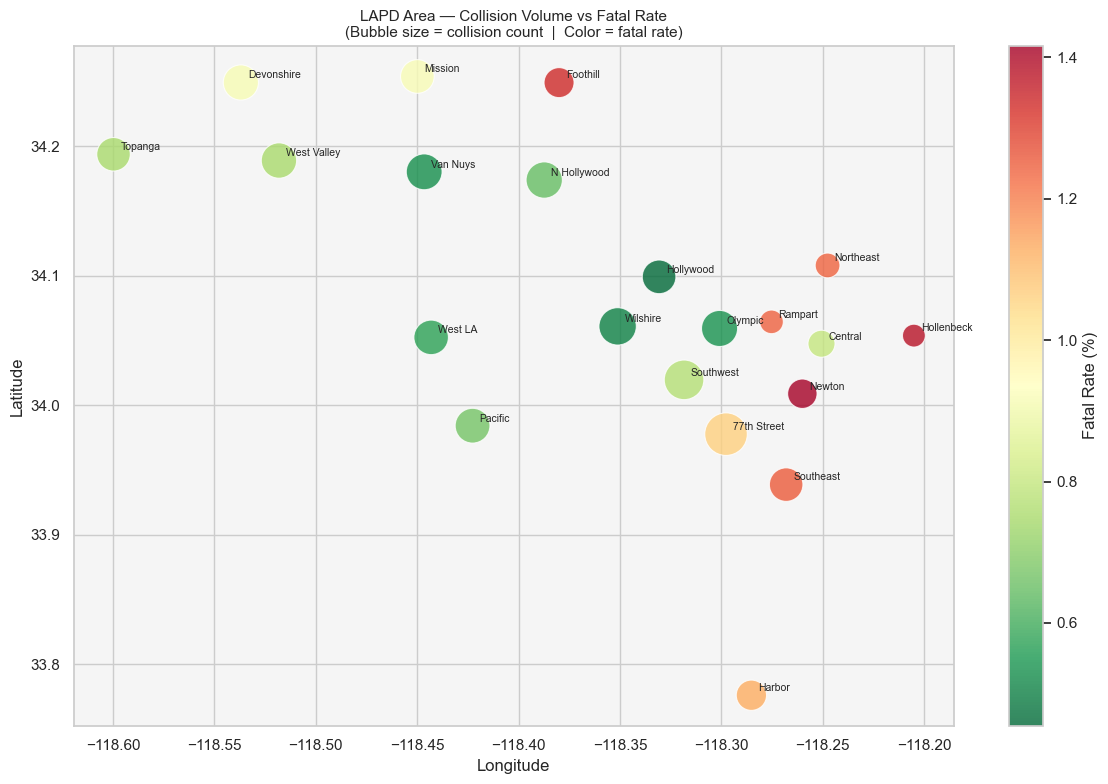

In [35]:
area_stats = df_sev.groupby('Area Name').agg(
    Total    = ('Severity', 'count'),
    Fatal_n  = ('Severity', lambda x: (x == 'Fatal').sum()),
    Lat_mean = ('Latitude', 'mean'),
    Lon_mean = ('Longitude', 'mean'),
).reset_index()
area_stats['Fatal_rate'] = area_stats['Fatal_n'] / area_stats['Total'] * 100

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    area_stats['Lon_mean'],
    area_stats['Lat_mean'],
    s=area_stats['Total'] / 30,
    c=area_stats['Fatal_rate'],
    cmap='RdYlGn_r', alpha=0.8, edgecolors='white', linewidth=0.8
)
plt.colorbar(sc, ax=ax, label='Fatal Rate (%)')

for _, row in area_stats.iterrows():
    ax.annotate(
        row['Area Name'],
        (row['Lon_mean'], row['Lat_mean']),
        textcoords='offset points', xytext=(5, 3), fontsize=7.5
    )

ax.set_title(
    'LAPD Area — Collision Volume vs Fatal Rate\n'
    '(Bubble size = collision count  |  Color = fatal rate)',
    fontsize=11
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_facecolor('#f5f5f5')

plt.tight_layout()
plt.savefig('fig_spatial_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save

In [36]:
# Save with all new features (before spatial risk score — that comes from DBSCAN+KDE step)
df_sev.to_csv('collisions_eda.csv', index=False)
print(f"Saved: collisions_eda.csv")
print(f"Shape: {df_sev.shape}")
print(f"\nKey columns for next step (DBSCAN + KDE):")
print("  Latitude, Longitude, Severity → feed into spatial analysis")
print("  spatial_risk_score will be added in next notebook")

Saved: collisions_eda.csv
Shape: (360687, 32)

Key columns for next step (DBSCAN + KDE):
  Latitude, Longitude, Severity → feed into spatial analysis
  spatial_risk_score will be added in next notebook


# Spatiotemporal Analysis — 
# Step 1: Severity Column & Filtering

MO Code reference (Traffic Collision codes):
| Code | Severity Label |
|------|----------------|
| 3027 | Fatal (K) |
| 3024 | Severe Injury (A) |
| 3025 | Visible Injury (B) |
| 3026 | Complaint of Pain (C) |
| 3028 | No Injury (N) |

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('collisions_clean.csv')
print(f'Loaded: {len(df):,} rows, {df.shape[1]} columns')
df.head(3)

Loaded: 452,646 rows, 13 columns


,DR Number,Date Occurred,Time Occurred,Area ID,Area Name,MO Codes,Victim Age,Victim Sex,Victim Descent,Location,datetime,Latitude,Longitude
0,212013850,09/02/2021,2335,20,Olympic,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,"(34.063, -118.3141)",2021-09-02 23:35:00,34.0630,-118.3141
1,222017859,12/01/2022,230,20,Olympic,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,"(34.0545, -118.3009)",2022-12-01 02:30:00,34.0545,-118.3009
2,190319651,08/24/2019,450,3,Southwest,3036 3004 3026 3101 4003,22.0,M,H,"(34.0255, -118.3002)",2019-08-24 04:50:00,34.0255,-118.3002


## 1. Extract Severity from MO Codes

Each row's `MO Codes` field is a space-separated string of codes.  
We scan for the traffic collision severity codes and map them to a label.  
Priority order (highest wins): **Fatal > Severe > Visible > Complaint > No Injury**

In [38]:
# Severity code → label mapping (priority: first match wins in order below)
SEVERITY_MAP = [
    ('3027', 'Fatal'),
    ('3024', 'Severe Injury'),
    ('3025', 'Visible Injury'),
    ('3026', 'Complaint of Pain'),
    ('3028', 'No Injury'),
]

def extract_severity(mo_str):
    """Return the highest-priority severity label found in the MO code string."""
    if pd.isna(mo_str):
        return 'Unknown'
    codes = set(mo_str.split())
    for code, label in SEVERITY_MAP:
        if code in codes:
            return label
    return 'Unknown'

df['Severity'] = df['MO Codes'].apply(extract_severity)

print('Severity column added!')
print(df['Severity'].value_counts())

Severity column added!
Severity
No Injury            148308
Complaint of Pain    135877
Unknown               91959
Visible Injury        58646
Severe Injury         14797
Fatal                  3059
Name: count, dtype: int64


## 2. Check Coverage

How many records got a valid severity label vs Unknown?

In [39]:
counts = df['Severity'].value_counts()
pct    = df['Severity'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': counts, 'Percent (%)': pct.round(2)})
print(summary)
print(f"\nUnknown (no severity MO code): {(df['Severity']=='Unknown').sum():,}")

                    Count  Percent (%)
Severity                              
No Injury          148308        32.76
Complaint of Pain  135877        30.02
Unknown             91959        20.32
Visible Injury      58646        12.96
Severe Injury       14797         3.27
Fatal                3059         0.68

Unknown (no severity MO code): 91,959


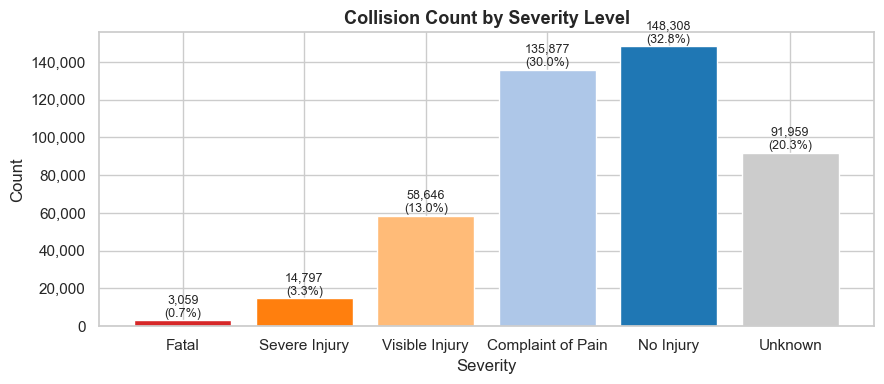

In [40]:
# Quick bar chart
order = ['Fatal', 'Severe Injury', 'Visible Injury', 'Complaint of Pain', 'No Injury', 'Unknown']
order = [o for o in order if o in counts.index]

colors = ['#d62728', '#ff7f0e', '#ffbb78', '#aec7e8', '#1f77b4', '#cccccc']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(order, [counts[o] for o in order], color=colors[:len(order)], edgecolor='white')

for bar, o in zip(bars, order):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{counts[o]:,}\n({pct[o]:.1f}%)", ha='center', va='bottom', fontsize=9)

ax.set_title('Collision Count by Severity Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Severity'); ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('severity_distribution.png', dpi=150)
plt.show()

## 3. Filter Fatal + Severe Injury Subset

This subset will be used as input to DBSCAN in the next step.

In [41]:
high_sev = df[df['Severity'].isin(['Fatal', 'Severe Injury'])].copy()

print(f'Full dataset    : {len(df):,} records')
print(f'Fatal           : {(df["Severity"]=="Fatal").sum():,}')
print(f'Severe Injury   : {(df["Severity"]=="Severe Injury").sum():,}')
print(f'High-sev subset : {len(high_sev):,} records ({100*len(high_sev)/len(df):.2f}% of total)')

Full dataset    : 452,646 records
Fatal           : 3,059
Severe Injury   : 14,797
High-sev subset : 17,856 records (3.94% of total)


## 4. Quick Sanity Check — Spot Check a Few Rows

In [42]:
# Show a few Fatal rows — confirm MO code 3027 is present
print('=== Sample Fatal rows ===')
display(df[df['Severity']=='Fatal'][['DR Number','MO Codes','Severity','Latitude','Longitude']].head(5))

print('\n=== Sample Severe Injury rows ===')
display(df[df['Severity']=='Severe Injury'][['DR Number','MO Codes','Severity','Latitude','Longitude']].head(5))

=== Sample Fatal rows ===


,DR Number,MO Codes,Severity,Latitude,Longitude
0,212013850,3004 3027 3034 4027 3036 3101 3401 3701,Fatal,34.0630,-118.3141
94,230118382,0605 3003 3027 3101 4024 3037 3401 3701 3033 3035,Fatal,34.0438,-118.2441
158,190814947,3003 3027 3035 3036 3101 3401 3701 4027,Fatal,34.0571,-118.3847
178,191008351,3003 3037 3027 3101 3701 4026 3401,Fatal,34.1800,-118.5360
348,191613372,3003 3027 3032 3037 3101 3401 3701 4026,Fatal,34.2597,-118.3140



=== Sample Severe Injury rows ===


,DR Number,MO Codes,Severity,Latitude,Longitude
38,230118036,3036 3101 4001 0605 3401 3701 3004 3024 3033 3035,Severe Injury,34.0714,-118.2329
49,190617883,3004 3024 3034 3036 3101 3401 3701 4027,Severe Injury,34.1112,-118.3358
62,230118194,3401 3701 0605 3008 3024 3029 3033 3037 3101 4024,Severe Injury,34.0693,-118.2284
82,190715683,3003 3024 3035 3036 3101 3401 3701 4007,Severe Injury,34.0496,-118.3425
89,230118346,3004 3024 3033 3035 3037 3101 4024,Severe Injury,34.0473,-118.2531


## 5. Save Outputs

In [43]:
# Save full dataset with Severity column added
df.to_csv('collisions_with_severity.csv', index=False)
print(f'Saved: collisions_with_severity.csv  ({len(df):,} rows)')

# Save high-severity subset separately (input for DBSCAN next)
high_sev.to_csv('collisions_high_severity.csv', index=False)
print(f'Saved: collisions_high_severity.csv  ({len(high_sev):,} rows)')

Saved: collisions_with_severity.csv  (452,646 rows)
Saved: collisions_high_severity.csv  (17,856 rows)


# Step 2: DBSCAN + KDE → Spatial Risk Score


In [44]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('collisions_eda.csv')
print(f'Loaded: {len(df):,} rows')
print(df['Severity'].value_counts())

Loaded: 360,687 rows
Severity
Non-Injury           148308
Complaint of Pain    135877
Visible Injury        58646
Severe Injury         14797
Fatal                  3059
Name: count, dtype: int64


## Part A — DBSCAN + KDE (Visualization)
Used to produce the spatial heatmap figures for the report.

In [45]:
# ── A1: Filter Fatal + Severe Injury ────────────────────────────
high_sev = df[df['Severity'].isin(['Fatal', 'Severe Injury'])].copy()
print(f'High-severity subset: {len(high_sev):,} records')
print(f'  Fatal         : {(high_sev["Severity"]=="Fatal").sum():,}')
print(f'  Severe Injury : {(high_sev["Severity"]=="Severe Injury").sum():,}')

High-severity subset: 17,856 records
  Fatal         : 3,059
  Severe Injury : 14,797


In [46]:
# ── A2: DBSCAN ──────────────────────────────────────────────────
# Tighter params (0.2km, min=15) to avoid giant blobs covering all of LA
coords_rad = np.radians(high_sev[['Latitude', 'Longitude']].values)

RADIUS_KM   = 0.2
MIN_SAMPLES = 15

db = DBSCAN(eps=RADIUS_KM / 6371.0, min_samples=MIN_SAMPLES,
            algorithm='ball_tree', metric='haversine')
high_sev['cluster_label'] = db.fit_predict(coords_rad)

n_clusters = len(set(high_sev['cluster_label'])) - 1
n_noise    = (high_sev['cluster_label'] == -1).sum()
n_core     = (high_sev['cluster_label'] != -1).sum()

print(f'DBSCAN (radius={RADIUS_KM}km, min_samples={MIN_SAMPLES})')
print(f'  Clusters : {n_clusters}')
print(f'  Core pts : {n_core:,}  ({100*n_core/len(high_sev):.1f}%)')
print(f'  Noise pts: {n_noise:,}  ({100*n_noise/len(high_sev):.1f}%)')
print(f'  Largest cluster: {high_sev[high_sev["cluster_label"]!=-1]["cluster_label"].value_counts().iloc[0]} pts')

DBSCAN (radius=0.2km, min_samples=15)
  Clusters : 128
  Core pts : 2,836  (15.9%)
  Noise pts: 15,020  (84.1%)
  Largest cluster: 116 pts


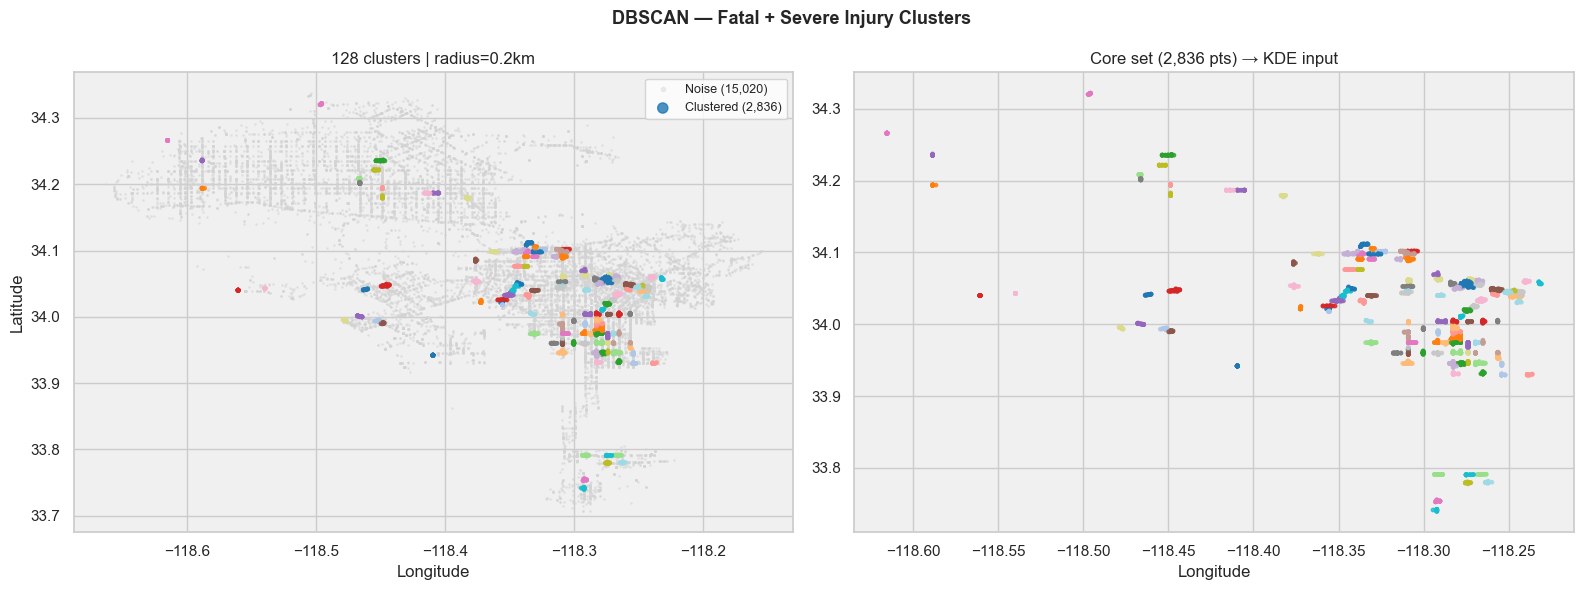

In [47]:
# ── A3: DBSCAN cluster map ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DBSCAN — Fatal + Severe Injury Clusters', fontsize=13, fontweight='bold')

noise = high_sev[high_sev['cluster_label'] == -1]
core  = high_sev[high_sev['cluster_label'] != -1]

axes[0].scatter(noise['Longitude'], noise['Latitude'],
                c='lightgray', s=1, alpha=0.4, label=f'Noise ({len(noise):,})', rasterized=True)
axes[0].scatter(core['Longitude'], core['Latitude'],
                c=core['cluster_label'], cmap='tab20', s=6, alpha=0.8,
                label=f'Clustered ({len(core):,})', rasterized=True)
axes[0].set_title(f'{n_clusters} clusters | radius={RADIUS_KM}km')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[0].legend(markerscale=3, fontsize=9)
axes[0].set_facecolor('#f0f0f0')

axes[1].scatter(core['Longitude'], core['Latitude'],
                c=core['cluster_label'], cmap='tab20', s=6, alpha=0.8, rasterized=True)
axes[1].set_title(f'Core set ({len(core):,} pts) → KDE input')
axes[1].set_xlabel('Longitude')
axes[1].set_facecolor('#f0f0f0')

plt.tight_layout()
plt.savefig('fig_dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

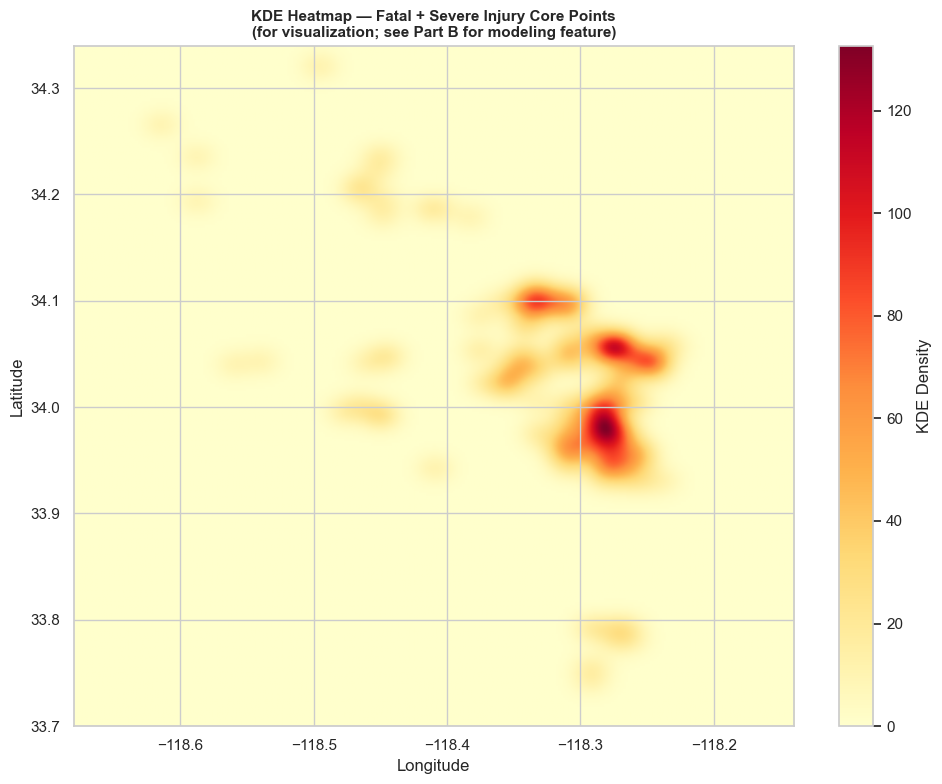

Saved → fig_kde_heatmap.png


In [48]:
# ── A4: KDE heatmap (visualization only) ────────────────────────
core_set    = high_sev[high_sev['cluster_label'] != -1]
coords_core = core_set[['Latitude', 'Longitude']].values

kde = KernelDensity(bandwidth=0.01, kernel='gaussian')
kde.fit(coords_core)

lat_grid = np.linspace(33.70, 34.34, 300)
lon_grid = np.linspace(-118.68, -118.14, 300)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
grid_dens = np.exp(kde.score_samples(np.c_[lat_mesh.ravel(), lon_mesh.ravel()])).reshape(300, 300)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(grid_dens, origin='lower', aspect='auto',
               extent=[-118.68, -118.14, 33.70, 34.34],
               cmap='YlOrRd', interpolation='bilinear')
plt.colorbar(im, ax=ax, label='KDE Density')
ax.set_title('KDE Heatmap — Fatal + Severe Injury Core Points\n(for visualization; see Part B for modeling feature)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('fig_kde_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → fig_kde_heatmap.png')

## Part B — Spatial Risk Score (Modeling Feature)

KDE scores every record ~0.38 regardless of severity because fatal collisions are spread city-wide.  
Instead, we compute the **area-level fatal rate** per LAPD division — a direct measure of how deadly each district is — and normalize it to [0, 1] as `spatial_risk_score`.

This produces a meaningful gradient and matches our spatial EDA findings (Newton, Hollenbeck = highest risk).

In [49]:
# ── B1: Compute area-level fatal rate ───────────────────────────
area_fatal_rate = (
    df.groupby('Area Name')
      .apply(lambda x: (x['Severity'] == 'Fatal').sum() / len(x))
      .rename('area_fatal_rate')
)

print('Fatal rate by LAPD area (ranked):')
print(area_fatal_rate.sort_values(ascending=False).round(4).to_string())

Fatal rate by LAPD area (ranked):
Area Name
Newton         0.0142
Hollenbeck     0.0138
Foothill       0.0134
Southeast      0.0125
Rampart        0.0124
Northeast      0.0124
Harbor         0.0113
77th Street    0.0106
Mission        0.0092
Devonshire     0.0091
Central        0.0080
Southwest      0.0077
Topanga        0.0075
West Valley    0.0075
Pacific        0.0067
N Hollywood    0.0065
West LA        0.0057
Olympic        0.0054
Van Nuys       0.0053
Wilshire       0.0051
Hollywood      0.0045


In [50]:
# ── B2: Assign spatial_risk_score to every record ───────────────
df = df.join(area_fatal_rate, on='Area Name')

r_min = df['area_fatal_rate'].min()
r_max = df['area_fatal_rate'].max()
df['spatial_risk_score'] = (df['area_fatal_rate'] - r_min) / (r_max - r_min)

print(f'spatial_risk_score range: {df["spatial_risk_score"].min():.4f} – {df["spatial_risk_score"].max():.4f}')

spatial_risk_score range: 0.0000 – 1.0000


Mean spatial_risk_score by severity:
Severity
Fatal                0.5139
Severe Injury        0.4514
Visible Injury       0.4246
Complaint of Pain    0.4319
Non-Injury           0.3764

✓ Fatal should be highest, Non-Injury lowest


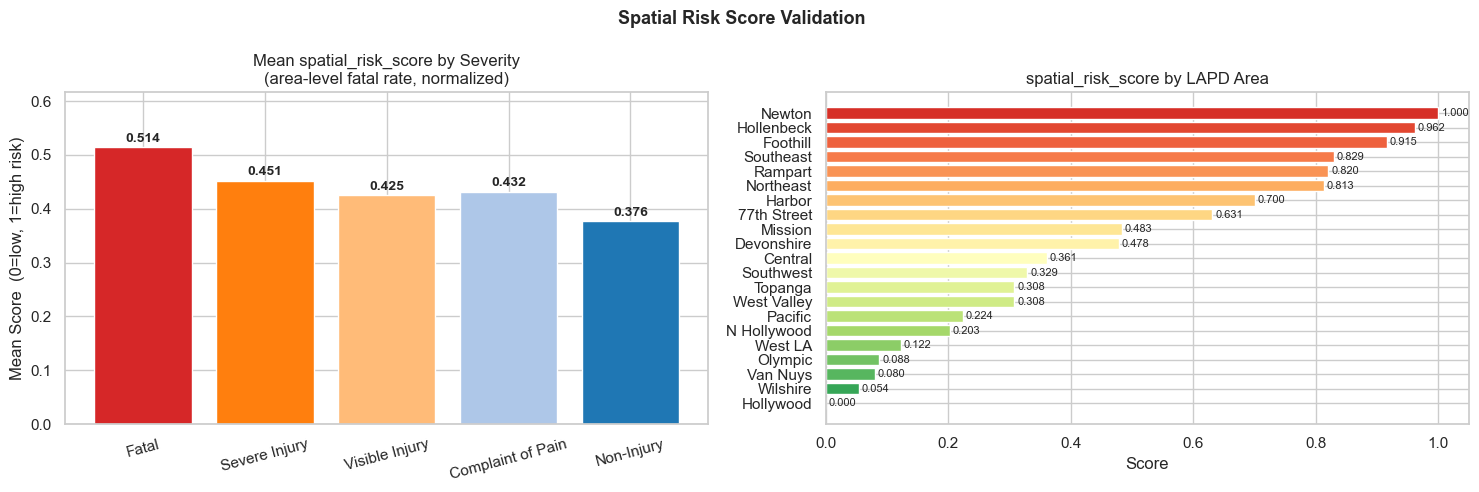

In [51]:
# ── B3: Validate — Fatal should have highest mean score ─────────
SEV_ORDER  = ['Fatal', 'Severe Injury', 'Visible Injury', 'Complaint of Pain', 'Non-Injury']
SEV_COLORS = ['#d62728', '#ff7f0e', '#ffbb78', '#aec7e8', '#1f77b4']

score_by_sev = df.groupby('Severity')['spatial_risk_score'].mean()\
                 .reindex([s for s in SEV_ORDER if s in df['Severity'].unique()])

print('Mean spatial_risk_score by severity:')
print(score_by_sev.round(4).to_string())
print('\n✓ Fatal should be highest, Non-Injury lowest')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Spatial Risk Score Validation', fontsize=13, fontweight='bold')

ax = axes[0]
valid_order  = [s for s in SEV_ORDER if s in score_by_sev.index]
valid_colors = [SEV_COLORS[SEV_ORDER.index(s)] for s in valid_order]
bars = ax.bar(valid_order, score_by_sev[valid_order].values,
              color=valid_colors, edgecolor='white')
for bar, val in zip(bars, score_by_sev[valid_order].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Mean spatial_risk_score by Severity\n(area-level fatal rate, normalized)')
ax.set_ylabel('Mean Score  (0=low, 1=high risk)')
ax.tick_params(axis='x', rotation=15)
ax.set_ylim(0, score_by_sev.max() * 1.2)

ax = axes[1]
area_scores = df.groupby('Area Name')['spatial_risk_score'].first().sort_values(ascending=True)
colors_bar  = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(area_scores)))
ax.barh(area_scores.index, area_scores.values, color=colors_bar, edgecolor='white')
ax.set_title('spatial_risk_score by LAPD Area')
ax.set_xlabel('Score')
for i, (area, val) in enumerate(area_scores.items()):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_risk_score_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## Save `collisions_final.csv`

In [52]:
# Drop the intermediate column before saving
df = df.drop(columns=['area_fatal_rate'])

df.to_csv('collisions_final.csv', index=False)
print('Saved: collisions_final.csv')
print(f'Shape : {df.shape}')
print()

rf_features = ['Hour', 'TimePeriod', 'IsWeekend', 'AgeGroup', 'Sex', 'Descent',
               'TC_VehVsPed', 'TC_VehVsBike', 'TC_VehVsVeh', 'TC_VehVsMC',
               'TC_HitRun', 'TC_AtIntersect', 'spatial_risk_score']
available = [f for f in rf_features if f in df.columns]
missing   = [f for f in rf_features if f not in df.columns]
print(f'Features ready for RF ({len(available)}): {available}')
if missing:
    print(f'Missing: {missing}')
print('\nNext → 03_random_forest.ipynb')

Saved: collisions_final.csv
Shape : (360687, 33)

Features ready for RF (13): ['Hour', 'TimePeriod', 'IsWeekend', 'AgeGroup', 'Sex', 'Descent', 'TC_VehVsPed', 'TC_VehVsBike', 'TC_VehVsVeh', 'TC_VehVsMC', 'TC_HitRun', 'TC_AtIntersect', 'spatial_risk_score']

Next → 03_random_forest.ipynb


# Step 3: Class Imbalance Handling + Random Forest Classification
**Input:** `collisions_final.csv` (output from Step 2)
**Output:** trained model + evaluation figures

### Design note
The dataset is heavily imbalanced — Fatal accounts for only 0.8% of records
(3,059 out of 360,687). A naive classifier would simply predict Non-Injury
every time and achieve ~41% accuracy while missing all Fatal cases.

We address this with class_weight='balanced', which automatically assigns
inverse-frequency weights to each class:
- Fatal weight       ≈ 48×  (rarely seen, penalized heavily if missed)
- Severe Injury      ≈ 10×
- Non-Injury         ≈  1×  (baseline)

Split: 70% train / 15% validation / 15% test, stratified on Severity.
Validation set is used for hyperparameter checks; test set for final report.
Special attention is given to recall for Fatal and Severe Injury classes.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('collisions_final.csv')
print(f'Loaded: {len(df):,} rows')
print(df['Severity'].value_counts())

Loaded: 360,687 rows
Severity
Non-Injury           148308
Complaint of Pain    135877
Visible Injury        58646
Severe Injury         14797
Fatal                  3059
Name: count, dtype: int64


In [54]:
# ## Part A — Feature Setup

# In[2]:

# ── A1: Define features & encode categoricals ────────────────────
FEATURES = [
    'Hour', 'DayOfWeek', 'IsWeekend', 'Month', 'TimePeriod',
    'AgeGroup', 'Sex', 'Descent',
    'spatial_risk_score',
    'TC_VehVsPed', 'TC_VehVsBike', 'TC_VehVsVeh', 'TC_VehVsMC',
    'TC_HitRun', 'TC_AtIntersect', 'flag_3038', 'flag_3040'
]

TARGET = 'Severity'

df_model = df[FEATURES + [TARGET]].copy()

cat_cols = ['AgeGroup', 'Sex', 'Descent', 'TimePeriod']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le  # saved for young female analysis in Part D

print(f'Features  : {len(FEATURES)}')
print(f'Cat cols encoded: {cat_cols}')
print(f'Target    : {TARGET}')

Features  : 17
Cat cols encoded: ['AgeGroup', 'Sex', 'Descent', 'TimePeriod']
Target    : Severity


In [55]:
# ## Part B — 70 / 15 / 15 Stratified Split

# In[3]:

# ── B1: First split — 70% train, 30% temp ───────────────────────
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ── B2: Second split — 15% val, 15% test ────────────────────────
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f'Train : {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val   : {len(X_val):,}   rows ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test  : {len(X_test):,}   rows ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nTrain severity distribution (stratified):')
print(y_train.value_counts())

Train : 252,480 rows (70%)
Val   : 54,103   rows (15%)
Test  : 54,104   rows (15%)

Train severity distribution (stratified):
Severity
Non-Injury           103815
Complaint of Pain     95114
Visible Injury        41052
Severe Injury         10358
Fatal                  2141
Name: count, dtype: int64


In [56]:
# ## Part C — Random Forest Training + Evaluation

# In[4]:

# ── C1: Train model ──────────────────────────────────────────────
# class_weight='balanced' handles imbalance — no synthetic data needed.
# Each class is weighted by: total_samples / (n_classes × class_count)
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print('Model trained!')
print(f'  Trees     : {rf.n_estimators}')
print(f'  Max depth : {rf.max_depth}')
print(f'  Classes   : {rf.classes_.tolist()}')

Model trained!
  Trees     : 200
  Max depth : 20
  Classes   : ['Complaint of Pain', 'Fatal', 'Non-Injury', 'Severe Injury', 'Visible Injury']


In [57]:
# In[5]:

# ── C2: Validation set evaluation ───────────────────────────────
# Used to check model behaviour before touching the test set
y_val_pred = rf.predict(X_val)

print('=== Validation Set Performance ===')
print(classification_report(y_val, y_val_pred, digits=4))

=== Validation Set Performance ===
                   precision    recall  f1-score   support

Complaint of Pain     0.6443    0.4563    0.5342     20381
            Fatal     0.1067    0.1830    0.1348       459
       Non-Injury     0.6750    0.8489    0.7520     22246
    Severe Injury     0.1991    0.3077    0.2418      2220
   Visible Injury     0.3365    0.2860    0.3092      8797

         accuracy                         0.5816     54103
        macro avg     0.3923    0.4164    0.3944     54103
     weighted avg     0.5840    0.5816    0.5718     54103



In [58]:
# In[6]:

# ── C3: Test set evaluation (final report numbers) ───────────────
y_test_pred = rf.predict(X_test)

print('=== Test Set Performance ===')
print(classification_report(y_test, y_test_pred, digits=4))

=== Test Set Performance ===
                   precision    recall  f1-score   support

Complaint of Pain     0.6446    0.4570    0.5348     20382
            Fatal     0.1195    0.2026    0.1504       459
       Non-Injury     0.6776    0.8459    0.7524     22247
    Severe Injury     0.2024    0.3119    0.2455      2219
   Visible Injury     0.3450    0.3012    0.3216      8797

         accuracy                         0.5835     54104
        macro avg     0.3978    0.4237    0.4009     54104
     weighted avg     0.5868    0.5835    0.5745     54104



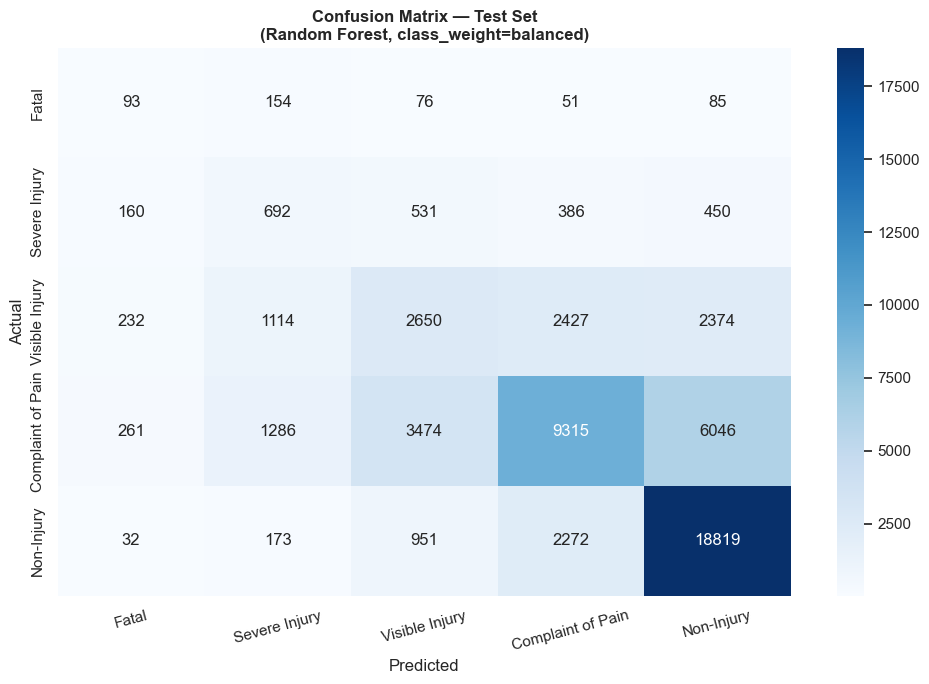

Saved → fig_confusion_matrix.png


In [59]:
# In[7]:

# ── C4: Confusion matrix ─────────────────────────────────────────
SEV_ORDER = ['Fatal', 'Severe Injury', 'Visible Injury', 'Complaint of Pain', 'Non-Injury']

cm = confusion_matrix(y_test, y_test_pred, labels=SEV_ORDER)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SEV_ORDER,
            yticklabels=SEV_ORDER,
            ax=ax)
ax.set_title('Confusion Matrix — Test Set\n(Random Forest, class_weight=balanced)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → fig_confusion_matrix.png')

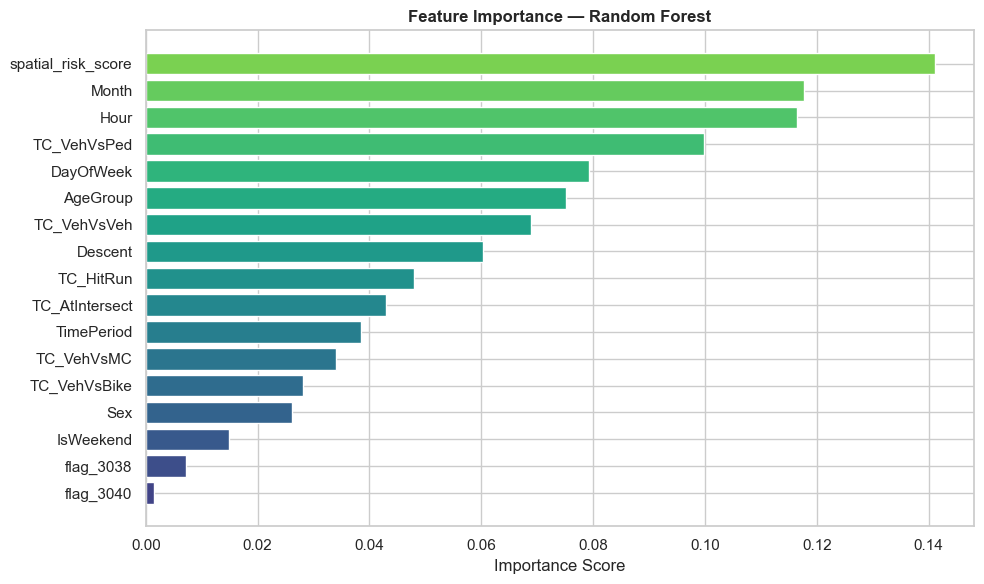

Feature importances:
spatial_risk_score    0.1411
Month                 0.1178
Hour                  0.1165
TC_VehVsPed           0.0999
DayOfWeek             0.0792
AgeGroup              0.0751
TC_VehVsVeh           0.0689
Descent               0.0603
TC_HitRun             0.0479
TC_AtIntersect        0.0429
TimePeriod            0.0384
TC_VehVsMC            0.0340
TC_VehVsBike          0.0281
Sex                   0.0261
IsWeekend             0.0149
flag_3038             0.0073
flag_3040             0.0015
Saved → fig_feature_importance.png


In [60]:
# In[8]:

# ── C5: Feature importance ───────────────────────────────────────
importances = pd.Series(
    rf.feature_importances_, index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(importances)))
ax.barh(importances.index[::-1], importances.values[::-1],
        color=colors, edgecolor='white')
ax.set_title('Feature Importance — Random Forest',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature importances:')
print(importances.round(4).to_string())
print('Saved → fig_feature_importance.png')

In [61]:
# ## Part D — Young Female Analysis
# Filters records where Victim Age < 25 and Victim Sex == 'F'
# and reports predicted severity probabilities for this subgroup —
# directly addressing the research question.

# In[9]:

# ── D1: Filter young female subset ──────────────────────────────
df_yf = df[
    (df['Victim Age'] >= 15) &
    (df['Victim Age'] <= 25) &
    (df['Victim Sex'] == 'F')
].copy()
print(f'Young female records : {len(df_yf):,}')
print(f'\nActual severity distribution:')
print(df_yf['Severity'].value_counts())

Young female records : 24,898

Actual severity distribution:
Severity
Complaint of Pain    10165
Non-Injury            9744
Visible Injury        4135
Severe Injury          763
Fatal                   91
Name: count, dtype: int64


In [62]:
# In[10]:

# ── D2: Encode + predict probabilities ──────────────────────────
df_yf_model = df_yf[FEATURES].copy()
for col in cat_cols:
    df_yf_model[col] = encoders[col].transform(
        df_yf_model[col].astype(str)
    )

proba    = rf.predict_proba(df_yf_model)
proba_df = pd.DataFrame(proba, columns=rf.classes_)

print('Mean predicted probability per severity class (young females):')
print(proba_df.mean().sort_values(ascending=False).round(4).to_string())

Mean predicted probability per severity class (young females):
Complaint of Pain    0.3152
Non-Injury           0.3144
Visible Injury       0.2354
Severe Injury        0.1040
Fatal                0.0310


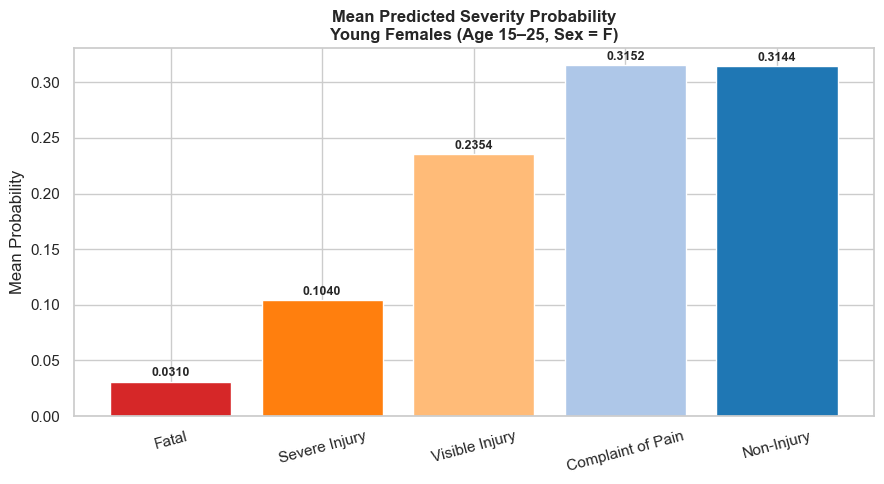

Saved → fig_young_female_proba.png


In [63]:
# In[11]:

# ── D3: Visualize young female severity probabilities ────────────
mean_proba = proba_df.mean().reindex(SEV_ORDER)
colors_sev = ['#d62728', '#ff7f0e', '#ffbb78', '#aec7e8', '#1f77b4']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(mean_proba.index, mean_proba.values,
              color=colors_sev, edgecolor='white')
for bar, val in zip(bars, mean_proba.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Mean Predicted Severity Probability\nYoung Females (Age 15–25, Sex = F)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Probability')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('fig_young_female_proba.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → fig_young_female_proba.png')